In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("src"))
from wAMEs.temporal_dynamics import integrate_I_traj_kernel
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from wAMEs.core import load_group_statistics

# Load group statistics
network = "CNS"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

nu = 9.5
mu = 1.0
w = 5.0
lam_kernel = 2e-3   # define here — currently missing, Cell 3 will NameError
scale = w           

# Output directory
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

In [3]:
def w_allegiance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    return scale * 4 * phi * (1 - phi)


Max trajectory deviation: 7.73e-01
Pass (atol=1e-10): False


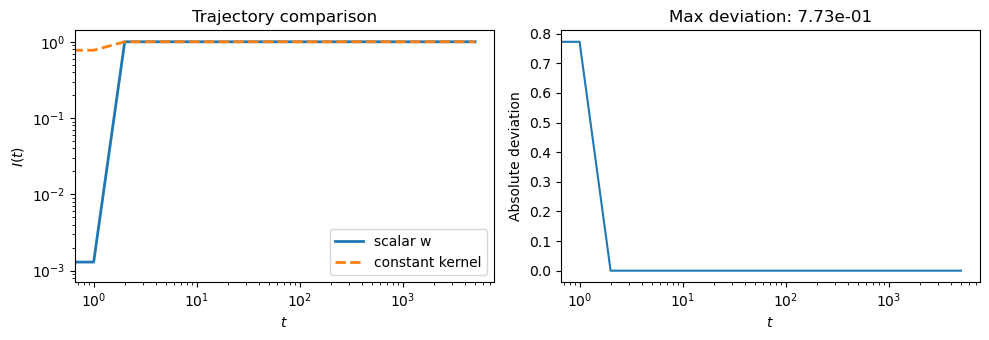

In [4]:
# --- Scalar limit verification ---
# A constant kernel w(n,i) = scale must reproduce integrate_I_traj exactly.
# Max deviation at machine precision (~1e-14) confirms S_w is correct.
# Larger deviation means the pnmat weighting in S_w is wrong.

from wAMEs.temporal_dynamics import integrate_I_traj

test_I0 = 1e-3
test_lam = lam_kernel  # 2e-3
test_traj_points = 5000  # coarse — just need trajectory shape, not resolution

# Scalar baseline
t_scalar, I_scalar = integrate_I_traj(
    lam=test_lam,
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    w=scale,       # w=5.0, same as scale
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

# Constant kernel — should be identical if S_w reduces correctly to I
t_kernel, I_kernel = integrate_I_traj_kernel(
    lam=test_lam,
    w_func=lambda n, i, s: s,   # constant: w(n,i) = scale
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

max_dev = np.max(np.abs(I_scalar - I_kernel))
print(f"Max trajectory deviation: {max_dev:.2e}")
print(f"Pass (atol=1e-10): {np.allclose(I_scalar, I_kernel, atol=1e-10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t_scalar, I_scalar, label="scalar w", lw=2)
axes[0].plot(t_kernel, I_kernel, "--", label="constant kernel", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("Trajectory comparison")
axes[0].legend()

axes[1].plot(t_scalar, np.abs(I_scalar - I_kernel))
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Absolute deviation")
axes[1].set_title(f"Max deviation: {max_dev:.2e}")

plt.tight_layout()
plt.show()

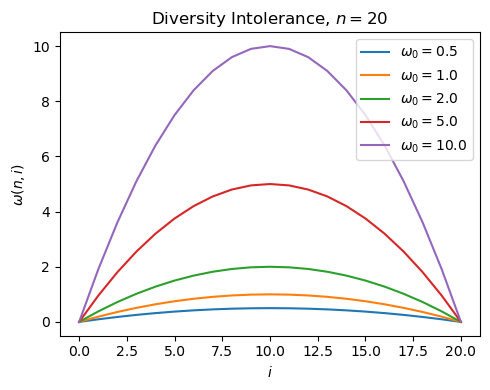

In [5]:
n = nmax  # e.g. nmax for Thiers13
i_vals = np.arange(0, n+1)
scales = [0.5, 1.0, 2.0, 5.0, 10.0]

fig, ax = plt.subplots(figsize=(5, 4))

for scale in scales:
    w_vals = [w_allegiance(n, i, scale) for i in i_vals]
    ax.plot(i_vals, w_vals, label=rf"$\omega_0={scale}$")

ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\omega(n,i)$")
ax.set_title(rf"Diversity Intolerance, $n={n}$")
ax.legend()
plt.tight_layout()
plt.savefig("src/wAMEs/figures/allegiance_kernel.png", dpi=300)
plt.show()